In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import scipy.stats as stats
import statsmodels.distributions.empirical_distribution as ECDF
# plt.rcParams['text.usetex'] = False  # forzar MathText

from source.models.autoregressive import AR
from source.utils import plot as uplot
from source.models.Inferencia import Inferencia_OLS
from source.models.bootstrap import Bootstrap
from source.utils.criticos import valores_criticos
from source.utils.graficopdf import graficopdf
from source.utils.graficochow import graficochow

In [2]:
phi = [0.8, -0.2]
model = AR(sigma=0.2, c=1, params_distribution=phi)
print(model)
print(model.autocov)

               AR(2) Model Summary                
Model Order (p)          : 2
Intercept (c)            : 1
Error Std Dev (sigma)    : 0.2
Is Stationary            : True
Mu (Unc. Mean):          : 2.5
Sigma (Unc. Std.)        : 0.27
Max Eigenvalue Modulus   : 0.4472
--------------------------------------------------
Coefficients (phi):
  phi_1    =     0.8000
  phi_2    =    -0.2000
[0.075 0.05 ]


In [20]:
np.random.seed(42)
# PREGUNTA 2.A: SIMULACIONES
R = np.array([[1,0,0], [0,1,4]]) # Restricciones
H0 = np.array([1,0]) # Valores bajo H0

simulaciones = []
inferencias = []
medias_iteraciones = []
varianza_iteraciones = []
for i in range(1000):
  muestra_actual = model.sample(n_samples=100)
  simulaciones.append(muestra_actual)
  muestra_actual = simulaciones[i]
  inferencia = Inferencia_OLS(muestra=muestra_actual, rezagos=2)
  inferencias.append(inferencia)
  medias_iteraciones.append(inferencia.get_momento1())
  varianza_iteraciones.append(inferencia.get_momento2())


# Para obtener el momento 1 estimado con Monte Carlo
momento1_estimado = np.mean(medias_iteraciones)
# Obtenemos la varianza estimada
momento2_estimado = np.mean(varianza_iteraciones)

In [26]:
#print(medias_iteraciones)
print(momento1_estimado)
print(momento2_estimado)
print(model.autovarianzas(orden=10))
print(inferencias[0].covarianzas(orden=10))

2.5002660763881535
0.0727917073741407
[ 7.500e-02  5.000e-02  2.500e-02  1.000e-02  3.000e-03  4.000e-04
 -2.800e-04 -3.040e-04 -1.872e-04 -8.896e-05]
[np.float64(0.056710438697723), np.float64(0.03597514007346941), np.float64(0.015734102954268046), np.float64(0.005879063158519967), np.float64(0.004006595510865648), np.float64(0.006846913917815717), np.float64(0.0019915130427365295), np.float64(-0.003496461033669885), np.float64(-0.00835022706115991), np.float64(-0.006687523684378664)]


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

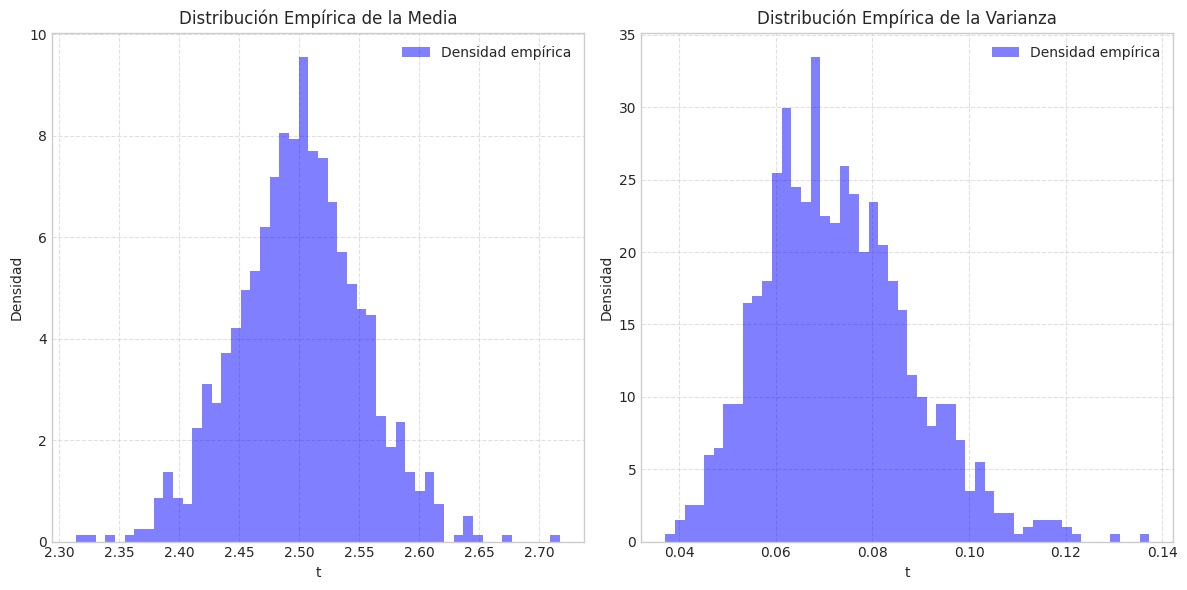

In [ ]:
# Parametros de la Distribución Empírica Acumulada ECDF
x1 = np.sort(medias_iteraciones)  # Ordeno los datos
n = x1.size
y1 = np.arange(1, n+1) / n

# Parametros de la distribucion de la varianza
x2 = np.sort(varianza_iteraciones)  # Ordeno los datos
n = x2.size
y2 = np.arange(1, n+1) / n

# Parámetros de la Distribución F Acumulada

# Creo la figura y los dos subgráficos
fig, (ax1, ax2) = plt.subplots(
     nrows=1, ncols=2, # Una fila, dos columnas
     figsize=(12, 6)   # Ajusta el tamaño si es necesario
    )
# --- Subgráfico 1: ECDF y CDF teórica ---
# AX1 para el gráfico 1
ax1.hist(medias_iteraciones, bins=50, density=True, alpha=0.5, color='blue', label='Densidad empírica')
ax1.set_xlabel('t')
ax1.set_ylabel('Densidad')
ax1.set_title('Distribución Empírica de la Media')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)  # Para mostrar la grilla
# --- Subgráfico 2: Densidad empírica y PDF teórica ---
# AX2 para el segundo gráfico
ax2.hist(varianza_iteraciones, bins=50, density=True, alpha=0.5, color='blue', label='Densidad empírica')
ax2.set_xlabel('t')
ax2.set_ylabel('Densidad')
ax2.set_title('Distribución Empírica de la Varianza')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6) # Para mostrar la grilla

# Ajustar layout y mostrar
fig.tight_layout()

plt.savefig(r'C:\Users\nicox\OneDrive\Escritorio\Estudios\Universidad\Semestre 10\Econometría II\Tareas\tarea1_prueba\HW1---Python-main\figuras\densidades1.jpeg',  transparent=True)
  

In [5]:
np.random.seed(42)
# PREGUNTA 2.B: TEST SIMPLE

R = np.array([[1,0,0], [0,1,4]]) # Restricciones
H0 = np.array([1,0]) # Valores bajo H0

testF = []
for i in range(1000):
  fobs = inferencias[i].hipotesis(R = R, nula = H0)
  testF.append(fobs)

testF = np.array(testF)

valores_criticos(testF)

Valor crítico al 1%: 4.975685643923875
Valor crítico al 5%: 3.3747054583639637
Valor crítico al 10%: 2.499557949752297


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

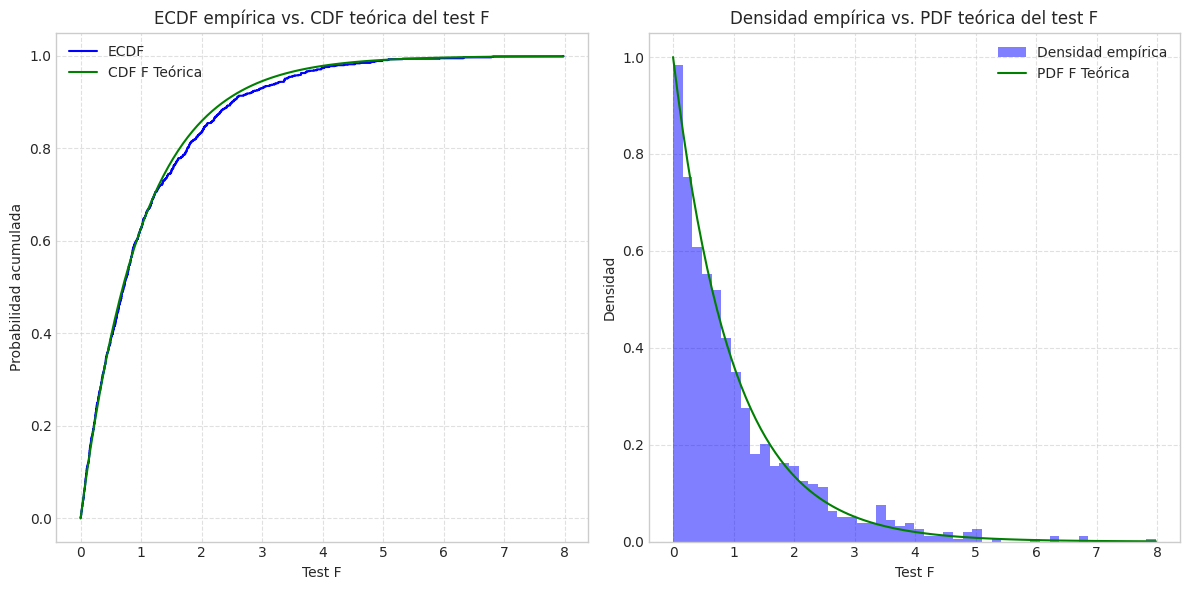

In [6]:
graficopdf(densidad=testF)
plt.savefig(r'C:\Users\nicox\OneDrive\Escritorio\Estudios\Universidad\Semestre 10\Econometría II\Tareas\tarea1_prueba\HW1---Python-main\figuras\graficotestF.jpeg',  transparent=True)
plt.show()

In [9]:
np.random.seed(42)
# PREGUNTA 2.C: Test de Chow

testChow = []
for i in range(1000):
  inf_actual = inferencias[i]
  chow = inf_actual.chow(quiebre = 50)
  testChow.append(chow)

testChow = np.array(testChow)

valores_criticos(testChow)

# Valores críticos
alpha_1 = stats.f.ppf(0.99, 3, 94)  # 1%
alpha_5 = stats.f.ppf(0.95, 3, 94)  # 5%
alpha_10 = stats.f.ppf(0.90, 3, 94)  # 10%

print("Valor crítico al 1% teórico:", alpha_1)
print("Valor crítico al 5% teórico:", alpha_5)
print("Valor crítico al 10% teórico:", alpha_10)

Valor crítico al 1%: 4.003889532152686
Valor crítico al 5%: 2.604394256806519
Valor crítico al 10%: 2.007723551099946
Valor crítico al 1% teórico: 3.997044236392674
Valor crítico al 5% teórico: 2.7014476340422786
Valor crítico al 10% teórico: 2.142983447026522


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

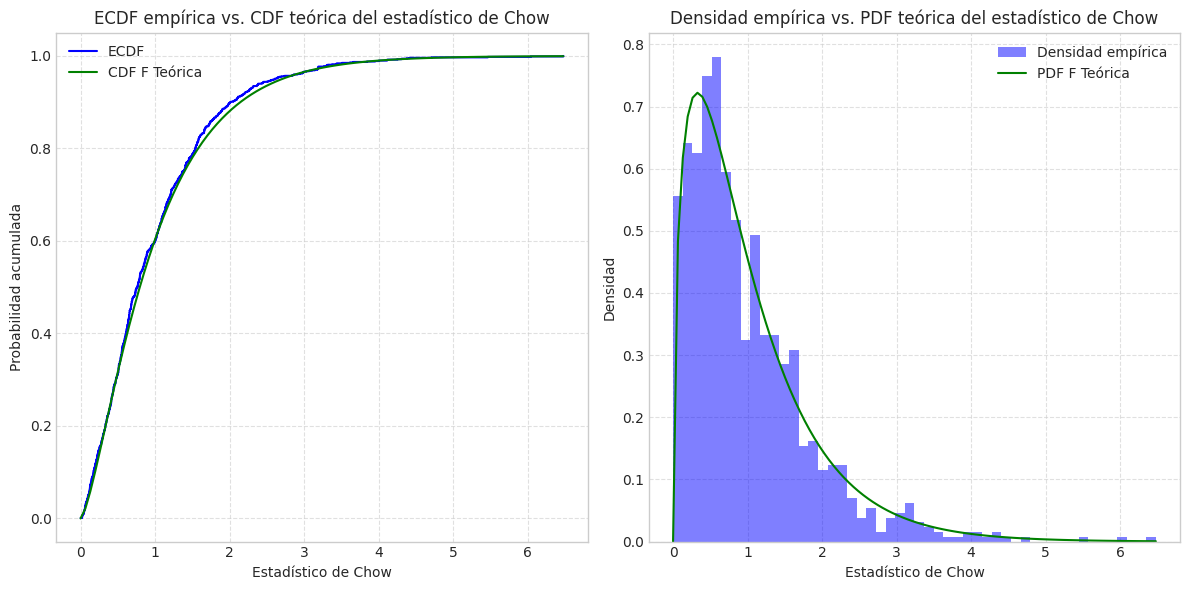

In [8]:
graficochow(densidad=testChow)
plt.savefig(r'C:\Users\nicox\OneDrive\Escritorio\Estudios\Universidad\Semestre 10\Econometría II\Tareas\tarea1_prueba\HW1---Python-main\figuras\grafico_chow.jpeg',  transparent=True)
plt.show()

In [38]:
# PREGUNTA 2.D: BOOTSTRAP
muestra = simulaciones[0]
# Hare 1000 remuestreos 
n_boot = 1000

remuestreo = Bootstrap(muestra=muestra, rezagos=2, n=n_boot)
remuestreo.Efron(1)
remuestreo.Hall(1)

R = np.array([[0,1,0]]) # Restricciones
H0 = np.array([0.8]) # Valores bajo H0

remuestreo.criticos(Rh=R, H0 = H0)

# Valores críticos
alpha_1 = stats.f.ppf(0.99, 3, 997)  # 1%
alpha_5 = stats.f.ppf(0.95, 3, 997)  # 5%
alpha_10 = stats.f.ppf(0.90, 3, 997)  # 10%

print("Valor crítico al 1% teórico:", alpha_1)
print("Valor crítico al 5% teórico:", alpha_5)
print("Valor crítico al 10% teórico:", alpha_10)

[np.float64(0.5893743195504906), np.float64(0.9059251157353658)] [np.float64(0.547433846025605), np.float64(0.9313003148854915)] [np.float64(0.49276847756661907), np.float64(0.9812552289880794)]
[np.float64(0.6183568994685991), np.float64(0.9349076956534743)] [np.float64(0.5929817003184734), np.float64(0.9768481691783599)] [np.float64(0.5430267862158855), np.float64(1.0315135376373459)]
Valor crítico al 1%: 4.130877929144324
Valor crítico al 5%: 2.3076963374633657
Valor crítico al 10%: 1.7279226523946614
Valor crítico al 1% teórico: 3.801305010844561
Valor crítico al 5% teórico: 2.613830399456913
Valor crítico al 10% teórico: 2.0892927046253504


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

(1000, 3)


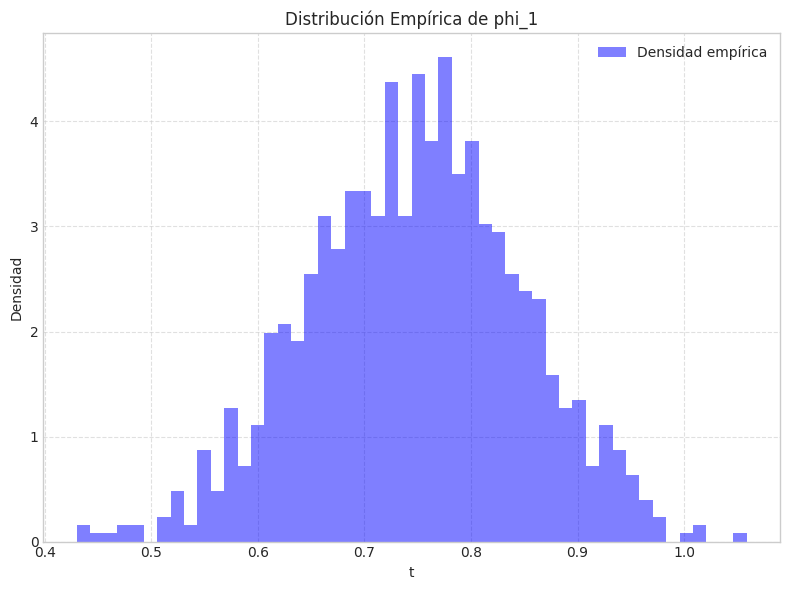

In [37]:
# Obtenemos los phi_1 estimados de cada iteración de bootstrap
phi_1_estimados = remuestreo.beta[:, 1]  # Accedemos a la segunda columna (phi_1)

# Parámetros de la Distribución F Acumulada

# Creo la figura y los dos subgráficos
fig, ax1 = plt.subplots(figsize=(8, 6))  # Una fila, un gráfico
# --- Subgráfico 1: ECDF y CDF teórica ---
# AX1 para el gráfico 1
ax1.hist(phi_1_estimados, bins=50, density=True, alpha=0.5, color='blue', label='Densidad empírica')
ax1.set_xlabel('t')
ax1.set_ylabel('Densidad')
ax1.set_title('Distribución Empírica de phi_1')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)  # Para mostrar la grilla


# Ajustar layout y mostrar
fig.tight_layout()

plt.savefig(r'C:\Users\nicox\OneDrive\Escritorio\Estudios\Universidad\Semestre 10\Econometría II\Tareas\tarea1_prueba\HW1---Python-main\figuras\2d.jpeg',  transparent=True)
  

print(remuestreo.beta.shape)
